# Defter 3: AUTSL - Transformer Tabanli Model Egitimi

## Amac
Bu defterin amaci, Defter 2'de islenmis ve kaydedilmis iskelet verilerini kullanarak
Turk Isaret Dili (TID) tanima icin bir **Transformer** modeli olusturmak ve egitmektir.

### Veri Seti Ozeti
- **226 sinif** (isaretler, aralik: 0-225)
- **80 kare** (zamansal boyut)
- **85 isaretci noktasi** x **3 koordinat** (uzamsal boyut)
- Train: ~28.130 | Val: ~4.416 | Test: ~3.739 ornek

### Islem Adimlari
1. **Veri Yukleme**: Defter 2'nin ciktilarindan `.npy` dosyalarinin okunmasi
2. **Veri Hazirlama**: Uzamsal boyutlarin duzlestirilerek `(Ornekler, 80, 255)` formatina donusturulmesi
3. **Model Mimarisi**: Transformer Encoder tabanli siniflandirici
4. **Egitim**: Callbacks ile model egitimi (EarlyStopping, ReduceLR, ModelCheckpoint)
5. **Degerlendirme**: Dogruluk ve kayip egrileri, nihai test sonuclari
6. **Kayit**: Model ve LabelEncoder'in kaydedilmesi

---
## 0. Kutuphanelerin Iceri Aktarilmasi ve Yapilandirma

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, top_k_accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
import gc

print(f"TensorFlow surumu: {tf.__version__}")
print(f"GPU kullanilabilir: {len(tf.config.list_physical_devices('GPU')) > 0}")

2026-02-10 17:28:06.348566: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770744486.558944      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770744486.615425      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770744487.057565      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770744487.057609      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770744487.057612      24 computation_placer.cc:177] computation placer alr

TensorFlow surumu: 2.19.0
GPU kullanilabilir: True


In [2]:
# =============================================================================
# Yapilandirma (Configuration)
# =============================================================================

# Girdi: Defter 2'nin ciktilari (Kaggle input olarak baglandi)
INPUT_DIR = "/kaggle/input/notebooks/ismailyahya/autsl-veri-isleme-ve-normalizasyon/AUTSL_Full_Processed"

# Cikti: Bu defterin sonuclari
OUTPUT_DIR = "/kaggle/working/AUTSL_Model"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Veri parametreleri (Defter 2 ile uyumlu olmali)
TARGET_FRAMES = 80
NUM_POINTS = 85
NUM_COORDS = 3
NUM_FEATURES = NUM_POINTS * NUM_COORDS  # 255

# Egitim parametreleri
EPOCHS = 200
BATCH_SIZE = 256
LR_MAX = 7e-4
WD_RATIO = 5e-5
N_WARMUP_EPOCHS = 15

print(f"Girdi Dizini:  {INPUT_DIR}")
print(f"Cikti Dizini:  {OUTPUT_DIR}")
print(f"Veri Sekli:    ({TARGET_FRAMES} Kare, {NUM_POINTS} Nokta, {NUM_COORDS} Koordinat)")
print(f"Ozellik Sayisi (duzlestirilmis): {NUM_FEATURES}")
print(f"Epoch Sayisi: {EPOCHS}, Batch Boyutu: {BATCH_SIZE}")
print(f"Maks Ogrenme Orani: {LR_MAX}, Agirlik Azalma: {WD_RATIO}")
print(f"Isinma Donemi: {N_WARMUP_EPOCHS} epoch")

Girdi Dizini:  /kaggle/input/notebooks/ismailyahya/autsl-veri-isleme-ve-normalizasyon/AUTSL_Full_Processed
Cikti Dizini:  /kaggle/working/AUTSL_Model
Veri Sekli:    (80 Kare, 85 Nokta, 3 Koordinat)
Ozellik Sayisi (duzlestirilmis): 255
Epoch Sayisi: 200, Batch Boyutu: 256
Maks Ogrenme Orani: 0.0007, Agirlik Azalma: 5e-05
Isinma Donemi: 15 epoch


---
## 1. Verilerin Yuklenmesi
Defter 2'de islenmis ve kaydedilmis `.npy` dosyalari dogrudan yuklenmektedir.
Train/Val/Test bolumleri zaten ayrilmistir; ek bir bolme islemi gerekmemektedir.

In [3]:
# Dosyalarin varliginin dogrulanmasi
required_files = [
    "X_train.npy", "y_train.npy",
    "X_val.npy",   "y_val.npy",
    "X_test.npy",  "y_test.npy",
]

print("Girdi dosyalarinin kontrolu:")
all_found = True
for fname in required_files:
    fpath = os.path.join(INPUT_DIR, fname)
    exists = os.path.exists(fpath)
    status = "BULUNDU" if exists else "BULUNAMADI"
    if exists:
        size_mb = os.path.getsize(fpath) / (1024**2)
        print(f"   {fname}: {status} ({size_mb:.1f} MB)")
    else:
        print(f"   {fname}: {status}")
        all_found = False

if all_found:
    print("\nTum dosyalar mevcut.")
else:
    raise FileNotFoundError("Gerekli dosyalar bulunamadi! Defter 2'nin ciktisini kontrol edin.")

Girdi dosyalarinin kontrolu:
   X_train.npy: BULUNDU (2189.1 MB)
   y_train.npy: BULUNDU (0.1 MB)
   X_val.npy: BULUNDU (343.7 MB)
   y_val.npy: BULUNDU (0.0 MB)
   X_test.npy: BULUNDU (291.0 MB)
   y_test.npy: BULUNDU (0.0 MB)

Tum dosyalar mevcut.


In [4]:
# Verilerin yuklenmesi
print("Veriler yukleniyor...")
start_time = time.time()

X_train = np.load(os.path.join(INPUT_DIR, "X_train.npy"))
y_train = np.load(os.path.join(INPUT_DIR, "y_train.npy"))
X_val   = np.load(os.path.join(INPUT_DIR, "X_val.npy"))
y_val   = np.load(os.path.join(INPUT_DIR, "y_val.npy"))
X_test  = np.load(os.path.join(INPUT_DIR, "X_test.npy"))
y_test  = np.load(os.path.join(INPUT_DIR, "y_test.npy"))

elapsed = time.time() - start_time
print(f"Yukleme suresi: {elapsed:.1f} saniye\n")

print("=" * 60)
print("YUKLENEN VERILER")
print("=" * 60)
for name, X, y in [("Train", X_train, y_train), ("Val", X_val, y_val), ("Test", X_test, y_test)]:
    print(f"\n[{name}]")
    print(f"   X: {X.shape}  (Ornekler, {TARGET_FRAMES} Kare, {NUM_POINTS} Nokta, {NUM_COORDS} Koordinat)")
    print(f"   y: {y.shape}, {len(np.unique(y))} benzersiz sinif")
    print(f"   Sinif araligi: {y.min()} - {y.max()}")
    print(f"   Bellek: {X.nbytes / (1024**3):.2f} GB")

Veriler yukleniyor...
Yukleme suresi: 16.9 saniye

YUKLENEN VERILER

[Train]
   X: (28130, 80, 85, 3)  (Ornekler, 80 Kare, 85 Nokta, 3 Koordinat)
   y: (28130,), 226 benzersiz sinif
   Sinif araligi: 0 - 225
   Bellek: 2.14 GB

[Val]
   X: (4416, 80, 85, 3)  (Ornekler, 80 Kare, 85 Nokta, 3 Koordinat)
   y: (4416,), 226 benzersiz sinif
   Sinif araligi: 0 - 225
   Bellek: 0.34 GB

[Test]
   X: (3739, 80, 85, 3)  (Ornekler, 80 Kare, 85 Nokta, 3 Koordinat)
   y: (3739,), 226 benzersiz sinif
   Sinif araligi: 0 - 225
   Bellek: 0.28 GB


---
## 2. Verilerin Hazirlanmasi

### 2.1 Etiket Kodlamasi (Label Encoding)
Sinif etiketleri 0-225 araliginda oldugu icin `LabelEncoder` kullanarak
etiquetlerin 0'dan `N-1`'e kadar ardisik olup olmadigini dogruluyoruz.
Bu, `sparse_categorical_crossentropy` kayip fonksiyonu icin onemlidir.

### 2.2 Uzamsal Boyutlarin Duzlestirilmesi
Transformer modeli zamansal bir dizi bekledigi icin,
uzamsal boyutlar (85 nokta x 3 koordinat) tek bir ozellik vektorune duzlestirilmektedir:
- Mevcut sekil: `(Ornekler, 80, 85, 3)`
- Hedef sekil:  `(Ornekler, 80, 255)` burada 255 = 85 x 3

In [5]:
# Etiket Kodlamasi
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

NUM_CLASSES = len(le.classes_)
print(f"Sinif sayisi: {NUM_CLASSES}")
print(f"Orijinal etiketler (ilk 10): {le.classes_[:10]}")
print(f"Son etiketler (son 10):      {le.classes_[-10:]}")

# Etiketlerin ardisik olup olmadiginin dogrulanmasi
expected = np.arange(NUM_CLASSES)
if np.array_equal(le.classes_, expected):
    print(f"Etiketler zaten ardisik (0-{NUM_CLASSES-1}). LabelEncoder kimlik donusumu yapmaktadir.")
else:
    print(f"Etiketler ardisik degil. LabelEncoder esleme uygulamaktadir.")

Sinif sayisi: 226
Orijinal etiketler (ilk 10): [0 1 2 3 4 5 6 7 8 9]
Son etiketler (son 10):      [216 217 218 219 220 221 222 223 224 225]
Etiketler zaten ardisik (0-225). LabelEncoder kimlik donusumu yapmaktadir.


In [6]:
# Uzamsal boyutlarin duzlestirilmesi
X_train_flat = X_train.reshape(X_train.shape[0], TARGET_FRAMES, NUM_FEATURES)
X_val_flat   = X_val.reshape(X_val.shape[0], TARGET_FRAMES, NUM_FEATURES)
X_test_flat  = X_test.reshape(X_test.shape[0], TARGET_FRAMES, NUM_FEATURES)

# Orijinal verileri bellekten sil (bellek tasarrufu)
del X_train, X_val, X_test
gc.collect()

print(f"Duzlestirilmis veri sekilleri:")
print(f"   X_train: {X_train_flat.shape}")
print(f"   X_val:   {X_val_flat.shape}")
print(f"   X_test:  {X_test_flat.shape}")
print(f"\nToplam bellek kullanimi: {(X_train_flat.nbytes + X_val_flat.nbytes + X_test_flat.nbytes) / (1024**3):.2f} GB")

Duzlestirilmis veri sekilleri:
   X_train: (28130, 80, 255)
   X_val:   (4416, 80, 255)
   X_test:  (3739, 80, 255)

Toplam bellek kullanimi: 2.76 GB


---
## 3. Model Mimarisi

### Transformer Encoder Tabanli Siniflandirici

Model alti ana bilesenden olusmaktadir:

1. **Ozellik Projeksiyon Katmani (Feature Projection)**: Giris ozelliklerini (255) gomme boyutuna (256) projekte eder
2. **Konumsal Gomme (Positional Embedding)**: Kare siralamasi bilgisini ekler
3. **Transformer Bloklari (x3)**: Cok basli dikkat (Multi-Head Attention) ve ileri besleme aglari
4. **Global Ortalama Havuzlama (Global Average Pooling)**: Zamansal boyutu daraltir
5. **Siniflandirma Basi (Classification Head)**: Dropout + Dense katmanlar
6. **Cikis Katmani**: 226 sinif icin Softmax

### Hiperparametre Tablosu

| Parametre | Deger | Aciklama |
|-----------|-------|----------|
| `embed_dim` | 256 | Transformer gomme boyutu |
| `num_heads` | 8 | Dikkat basi sayisi |
| `ff_dim` | 768 | Ileri besleme ag boyutu (embed_dim x 3) |
| `num_layers` | 3 | Transformer blok sayisi |
| `dropout_rate` | 0.40 | Dropout orani (guclu regularizasyon) |
| `label_smoothing` | 0.1 | Etiket yumusatma (asiri guven engelleyici) |

In [7]:
class SparseCategoricalCrossentropyWithLS(keras.losses.Loss):
    """
    Sparse Categorical Crossentropy with Label Smoothing.
    SparseCategoricalCrossentropy label_smoothing desteklememektedir,
    bu sinif sparse etiketleri one-hot formatina donusturerek
    label smoothing uygular.
    """
    def __init__(self, num_classes, label_smoothing=0.0, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes
        self.label_smoothing = label_smoothing

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_one_hot = tf.one_hot(y_true, self.num_classes)
        y_true_smooth = y_true_one_hot * (1.0 - self.label_smoothing) + (self.label_smoothing / tf.cast(self.num_classes, tf.float32))
        return tf.reduce_mean(keras.losses.categorical_crossentropy(y_true_smooth, y_pred))

    def get_config(self):
        config = super().get_config()
        config.update({"num_classes": self.num_classes, "label_smoothing": self.label_smoothing})
        return config


class TransformerBlock(layers.Layer):
    """
    Tek bir Transformer Encoder blogu.
    Icerir: Multi-Head Attention + Feed-Forward Network + Layer Normalization + Dropout
    """
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        # Multi-Head Self-Attention + Artik Baglanti
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        
        # Feed-Forward Network + Artik Baglanti
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


class PositionalEmbedding(layers.Layer):
    """
    Ogrenilebilir konumsal gomme katmani.
    Her kare konumuna ozel bir vektor ekler.
    """
    def __init__(self, maxlen, embed_dim):
        super().__init__()
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        return x + positions


print("TransformerBlock ve PositionalEmbedding siniflari tanimlandi.")

TransformerBlock ve PositionalEmbedding siniflari tanimlandi.


In [8]:
def build_model(n_frames, n_features, n_classes):
    """
    Transformer Encoder tabanli siniflandirma modeli olusturur.
    
    Parametreler:
        n_frames:   Zamansal boyut (80)
        n_features: Uzamsal ozellik boyutu (255 = 85 x 3)
        n_classes:  Sinif sayisi (226)
    """
    # Hiperparametreler
    embed_dim = 256       # Gomme boyutu
    num_heads = 8         # Dikkat basi sayisi
    ff_dim = embed_dim * 3  # MLP ratio = 3 (768)
    num_layers = 3        # Transformer blok sayisi
    dropout_rate = 0.40   # Dropout orani (guclu regularizasyon)

    # Giris
    inputs = layers.Input(shape=(n_frames, n_features), name="input")

    # 1. Ozellik Projeksiyon: (80, 255) -> (80, 256)
    x = layers.Dense(embed_dim, name="feature_projection")(inputs)

    # 2. Konumsal Gomme
    x = PositionalEmbedding(maxlen=n_frames, embed_dim=embed_dim)(x)

    # 3. Transformer Bloklari
    for i in range(num_layers):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

    # 4. Global Ortalama Havuzlama: (80, 256) -> (256,)
    x = layers.GlobalAveragePooling1D(name="global_avg_pool")(x)

    # 5. Siniflandirma Basi (guclu dropout ile)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(embed_dim, activation="gelu", name="cls_dense_1")(x)
    x = layers.Dropout(dropout_rate)(x)

    # 6. Cikis Katmani
    outputs = layers.Dense(n_classes, activation="softmax", name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model


# Model olusturma
model = build_model(TARGET_FRAMES, NUM_FEATURES, NUM_CLASSES)

# Model derleme - AdamW optimizer ile (gradient clip + weight decay)
# Label smoothing (0.1) ile asiri guveni engelleyerek genellemeyi iyilestiriyoruz
model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=LR_MAX,
        weight_decay=WD_RATIO,
        clipnorm=1.0  # Gradyan patlamasini onler!
    ),
    loss=SparseCategoricalCrossentropyWithLS(num_classes=NUM_CLASSES, label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()

# Toplam parametre sayisi
total_params = model.count_params()
print(f"\nToplam parametre sayisi: {total_params:,} ({total_params / 1e6:.2f}M)")

I0000 00:00:1770744517.752103      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 80, 255)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_projection (Dense)      │ (None, 80, 256)        │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 80, 256)        │        20,480 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 80, 256)        │     2,498,816 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 80, 256)        │     2,498,816 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 80, 256)        │     2,498,816 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cls_dense_1 (Dense)             │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 226)            │        58,082 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,706,338 (29.40 MB)

 Trainable params: 7,706,338 (29.40 MB)

 Non-trainable params: 0 (0.00 B)


Toplam parametre sayisi: 7,706,338 (7.71M)


---
## 4. Model Egitimi

### Kullanilan Callback'ler:
- **ModelCheckpoint**: En iyi dogrulama dogruluguna sahip modeli kaydeder
- **EarlyStopping**: 40 epoch boyunca iyilesme olmazsa egitimi durdurur
- **LearningRateScheduler**: Cosine decay + warmup ogrenme orani programi

Callback'ler tanimlandi.
En iyi model kayit yolu: /kaggle/working/AUTSL_Model/best_model_transformer.keras
Epoch sayisi: 200
Batch boyutu: 256
Maks ogrenme orani: 0.0007
Isinma donemi: 15 epoch
Agirlik azalma orani: 5e-05


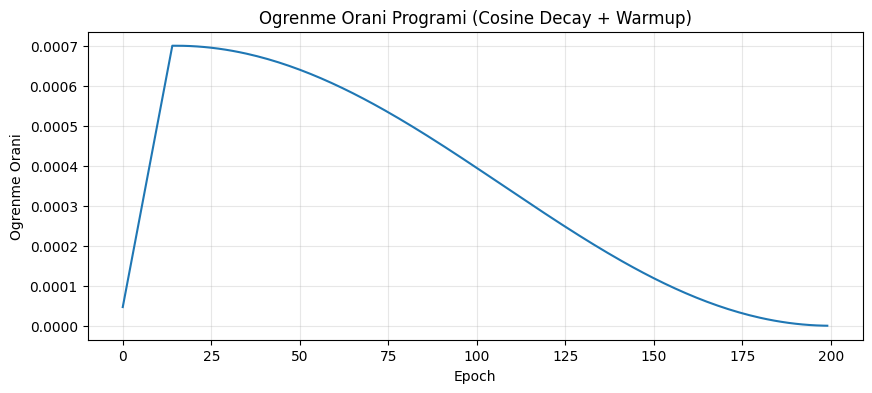

In [9]:
# Ogrenme orani programi (Cosine Decay with Warmup)
def lrfn(epoch):
    """
    Cosine decay + warmup ogrenme orani programi.
    """
    if epoch < N_WARMUP_EPOCHS:
        # Isinma: 0 -> LR_MAX
        lr = (LR_MAX / N_WARMUP_EPOCHS) * (epoch + 1)
    else:
        # Cosine decay: LR_MAX -> 0
        progress = (epoch - N_WARMUP_EPOCHS) / (EPOCHS - N_WARMUP_EPOCHS)
        lr = LR_MAX * (0.5 * (1.0 + np.cos(np.pi * progress)))
    return lr

# Callback'lerin tanimlanmasi
best_model_path = os.path.join(OUTPUT_DIR, "best_model_transformer.keras")

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        save_best_only=True,
        monitor="val_accuracy",
        mode="max",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=40,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.LearningRateScheduler(lrfn, verbose=1),
]

print("Callback'ler tanimlandi.")
print(f"En iyi model kayit yolu: {best_model_path}")
print(f"Epoch sayisi: {EPOCHS}")
print(f"Batch boyutu: {BATCH_SIZE}")
print(f"Maks ogrenme orani: {LR_MAX}")
print(f"Isinma donemi: {N_WARMUP_EPOCHS} epoch")
print(f"Agirlik azalma orani: {WD_RATIO}")

# Ogrenme orani programini gorselleştir
lr_schedule = [lrfn(epoch) for epoch in range(EPOCHS)]
plt.figure(figsize=(10, 4))
plt.plot(lr_schedule)
plt.title("Ogrenme Orani Programi (Cosine Decay + Warmup)")
plt.xlabel("Epoch")
plt.ylabel("Ogrenme Orani")
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Egitim
print("=" * 60)
print("MODEL EGITIMI BASLIYOR")
print("=" * 60)

train_start = time.time()

history = model.fit(
    X_train_flat, y_train_enc,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val_flat, y_val_enc),
    callbacks=callbacks,
    verbose=1
)

train_elapsed = time.time() - train_start
print(f"\nToplam egitim suresi: {train_elapsed / 60:.1f} dakika")
print(f"Gerceklesen epoch sayisi: {len(history.history['loss'])}")

MODEL EGITIMI BASLIYOR

Epoch 1: LearningRateScheduler setting learning rate to 4.6666666666666665e-05.
Epoch 1/200


I0000 00:00:1770744533.590709      66 service.cc:152] XLA service 0x7a085c00b170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770744533.590760      66 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770744536.011991      66 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1770744545.642137      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.0049 - loss: 5.5375
Epoch 1: val_accuracy improved from -inf to 0.01947, saving model to /kaggle/working/AUTSL_Model/best_model_transformer.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 61s 366ms/step - accuracy: 0.0049 - loss: 5.5369 - val_accuracy: 0.0195 - val_loss: 5.3368 - learning_rate: 4.6667e-05

Epoch 2: LearningRateScheduler setting learning rate to 9.333333333333333e-05.
Epoch 2/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.0140 - loss: 5.3514
Epoch 2: val_accuracy improved from 0.01947 to 0.05186, saving model to /kaggle/working/AUTSL_Model/best_model_transformer.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 25s 224ms/step - accuracy: 0.0141 - loss: 5.3506 - val_accuracy: 0.0519 - val_loss: 4.7473 - learning_rate: 9.3333e-05

Epoch 3: LearningRateScheduler setting learning rate to 0.00014.
Epoch 3/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.0350 - loss: 4.9521
Epoch 3: val_accuracy improved from 0.05186 to 0

---
## 5. Egitim Sonuclarinin Gorsellestirmesi

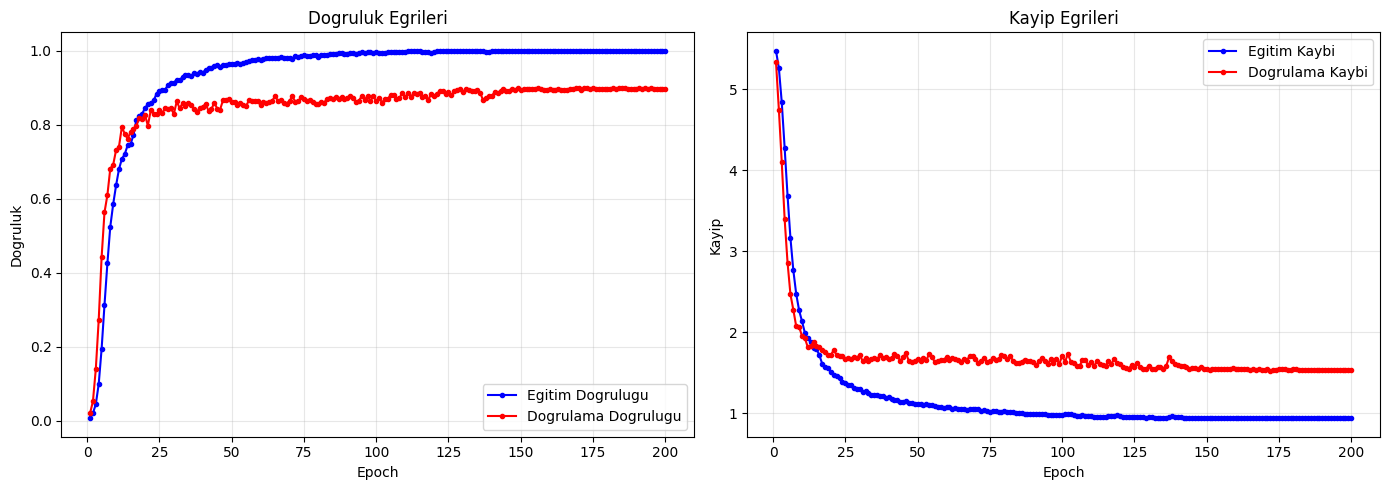

Grafikler kaydedildi.


In [11]:
def plot_history(history):
    """
    Egitim ve dogrulama dogruluk/kayip egrilerini cizer.
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    lr = history.history.get('lr', None)
    epochs = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 3 if lr else 2, figsize=(18 if lr else 14, 5))

    # Dogruluk Egrisi
    axes[0].plot(epochs, acc, 'b-o', markersize=3, label='Egitim Dogrulugu')
    axes[0].plot(epochs, val_acc, 'r-o', markersize=3, label='Dogrulama Dogrulugu')
    axes[0].set_title('Dogruluk Egrileri')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Dogruluk')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Kayip Egrisi
    axes[1].plot(epochs, loss, 'b-o', markersize=3, label='Egitim Kaybi')
    axes[1].plot(epochs, val_loss, 'r-o', markersize=3, label='Dogrulama Kaybi')
    axes[1].set_title('Kayip Egrileri')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Kayip')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Ogrenme Orani Egrisi (varsa)
    if lr:
        axes[2].plot(epochs, lr, 'g-o', markersize=3)
        axes[2].set_title('Ogrenme Orani')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Ogrenme Orani')
        axes[2].set_yscale('log')
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "egitim_grafikleri.png"), dpi=150, bbox_inches='tight')
    plt.show()
    print("Grafikler kaydedildi.")


plot_history(history)

---
## 6. Test Seti Uzerinde Nihai Degerlendirme

Test seti uzerinde kapsamli bir degerlendirme yapilmaktadir:
- **Dogruluk (Accuracy)**: Genel basari orani
- **F1 Skoru**: Precision ve Recall'in harmonik ortalamasi (macro ve weighted)
- **Precision ve Recall**: Sinif bazli dogruluk metrikleri
- **Top-5 Dogruluk**: Dogru sinifin ilk 5 tahmin arasinda olma orani
- **Siniflandirma Raporu**: Her sinif icin ayrintili metrikler
- **Karisiklik Matrisi (Confusion Matrix)**: Tahmin dagilimi gorsellestirmesi

In [12]:
# =============================================================================
# Test Seti Uzerinde Kapsamli Degerlendirme
# =============================================================================
print("=" * 60)
print("TEST SETI DEGERLENDIRMESI")
print("=" * 60)

# 1. Temel metrikler
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test_enc, verbose=1)
print(f"\nTest Kaybi:     {test_loss:.4f}")
print(f"Test Dogrulugu: {test_accuracy * 100:.2f}%")

# 2. Tahminlerin elde edilmesi
y_pred_probs = model.predict(X_test_flat, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. F1 Skoru (Macro ve Weighted)
f1_macro = f1_score(y_test_enc, y_pred, average='macro')
f1_weighted = f1_score(y_test_enc, y_pred, average='weighted')
print(f"\nF1 Skoru (Macro):    {f1_macro:.4f}")
print(f"F1 Skoru (Weighted): {f1_weighted:.4f}")

# 4. Precision ve Recall
precision_macro = precision_score(y_test_enc, y_pred, average='macro')
precision_weighted = precision_score(y_test_enc, y_pred, average='weighted')
recall_macro = recall_score(y_test_enc, y_pred, average='macro')
recall_weighted = recall_score(y_test_enc, y_pred, average='weighted')
print(f"\nPrecision (Macro):    {precision_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Macro):       {recall_macro:.4f}")
print(f"Recall (Weighted):    {recall_weighted:.4f}")

# 5. Top-5 Dogruluk
top5_accuracy = top_k_accuracy_score(y_test_enc, y_pred_probs, k=5)
print(f"\nTop-5 Dogruluk: {top5_accuracy * 100:.2f}%")

# 6. Dogrulama seti sonuclari
val_loss, val_accuracy = model.evaluate(X_val_flat, y_val_enc, verbose=0)
print(f"\nDogrulama Kaybi:     {val_loss:.4f}")
print(f"Dogrulama Dogrulugu: {val_accuracy * 100:.2f}%")

# 7. En iyi sonuclar
best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1
print(f"\nEn Iyi Dogrulama Dogrulugu: {best_val_acc * 100:.2f}% (Epoch {best_epoch})")

TEST SETI DEGERLENDIRMESI
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8965 - loss: 1.5354

Test Kaybi:     1.4497
Test Dogrulugu: 90.96%

F1 Skoru (Macro):    0.9088
F1 Skoru (Weighted): 0.9095

Precision (Macro):    0.9156
Precision (Weighted): 0.9170
Recall (Macro):       0.9101
Recall (Weighted):    0.9096

Top-5 Dogruluk: 98.26%

Dogrulama Kaybi:     1.5267
Dogrulama Dogrulugu: 89.99%

En Iyi Dogrulama Dogrulugu: 89.99% (Epoch 172)


In [13]:
# =============================================================================
# Siniflandirma Raporu (Classification Report)
# =============================================================================
print("=" * 60)
print("SINIFLANDIRMA RAPORU")
print("=" * 60)

# Sinif isimlerini olustur
class_names = [str(c) for c in le.classes_]

# Siniflandirma raporu
report = classification_report(
    y_test_enc, y_pred,
    target_names=class_names,
    digits=4,
    output_dict=True
)

# Raporu DataFrame olarak goster (ilk 20 sinif)
report_df = pd.DataFrame(report).transpose()
print("\nIlk 20 sinifin detayli sonuclari:")
print(report_df.head(20).to_string())

# Macro ve weighted ortalamalar
print("\n--- Genel Ortalamalar ---")
macro = report["macro avg"]
weighted = report["weighted avg"]
print(f"Macro Avg    -> Precision: {macro['precision']:.4f}, Recall: {macro['recall']:.4f}, F1: {macro['f1-score']:.4f}")
print(f"Weighted Avg -> Precision: {weighted['precision']:.4f}, Recall: {weighted['recall']:.4f}, F1: {weighted['f1-score']:.4f}")

# Raporu CSV olarak kaydet
report_path = os.path.join(OUTPUT_DIR, "classification_report.csv")
report_df.to_csv(report_path)
print(f"\nSiniflandirma raporu kaydedildi: {report_path}")

SINIFLANDIRMA RAPORU

Ilk 20 sinifin detayli sonuclari:
    precision    recall  f1-score  support
0    0.812500  0.812500  0.812500     16.0
1    1.000000  0.937500  0.967742     16.0
2    1.000000  1.000000  1.000000     17.0
3    1.000000  0.941176  0.969697     17.0
4    1.000000  0.941176  0.969697     17.0
5    1.000000  0.823529  0.903226     17.0
6    0.692308  0.529412  0.600000     17.0
7    0.866667  0.764706  0.812500     17.0
8    0.846154  0.647059  0.733333     17.0
9    0.941176  0.941176  0.941176     17.0
10   0.894737  1.000000  0.944444     17.0
11   1.000000  1.000000  1.000000     16.0
12   0.937500  1.000000  0.967742     15.0
13   0.695652  1.000000  0.820513     16.0
14   1.000000  1.000000  1.000000     17.0
15   1.000000  1.000000  1.000000     15.0
16   0.785714  0.785714  0.785714     14.0
17   0.647059  0.687500  0.666667     16.0
18   1.000000  1.000000  1.000000     17.0
19   1.000000  0.941176  0.969697     17.0

--- Genel Ortalamalar ---
Macro Avg    -

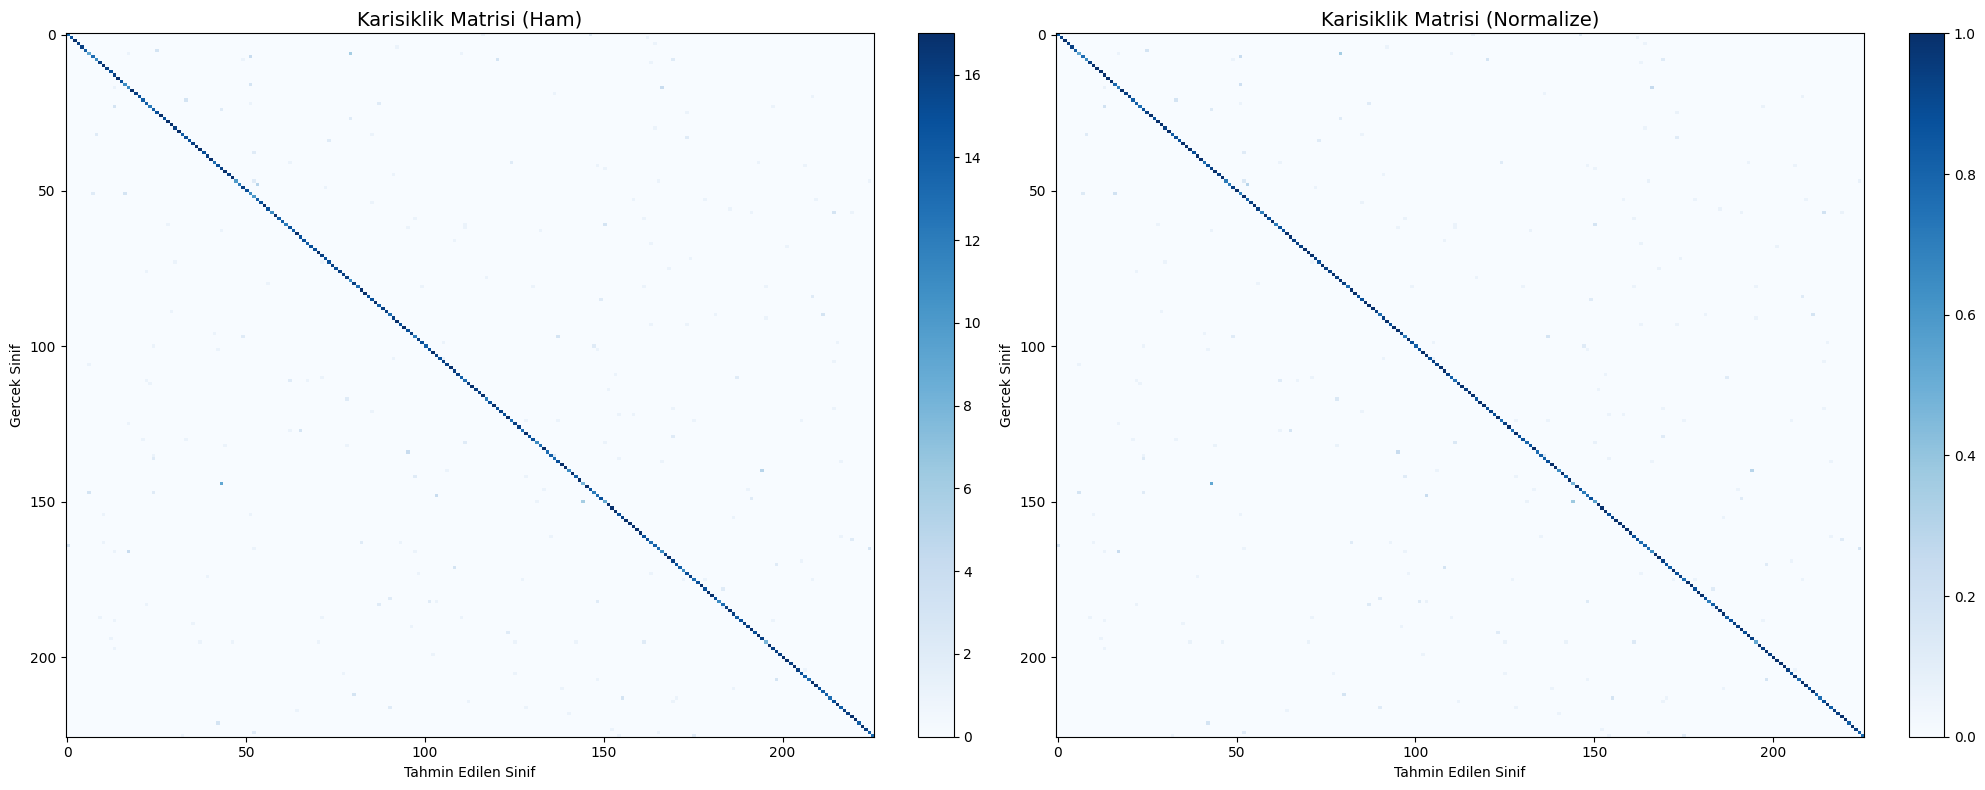


En Dusuk Performansli 10 Sinif:
   Sinif |   Dogruluk | Ornek Sayisi
------------------------------------
     144 |     47.06% |           17
       6 |     52.94% |           17
     195 |     53.33% |           15
     150 |     56.25% |           16
     140 |     64.71% |           17
       8 |     64.71% |           17
     166 |     64.71% |           17
      17 |     68.75% |           16
      51 |     68.75% |           16
      57 |     68.75% |           16

Karisiklik matrisi kaydedildi.


In [14]:
# =============================================================================
# Karisiklik Matrisi (Confusion Matrix) Gorsellestirmesi
# =============================================================================
cm = confusion_matrix(y_test_enc, y_pred)

# Normalize edilmis karisiklik matrisi
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

# Gorsellestirme (226 sinif cok buyuk oldugundan, genel gorunum)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Ham karisiklik matrisi
im1 = axes[0].imshow(cm, cmap="Blues", aspect="auto")
axes[0].set_title("Karisiklik Matrisi (Ham)", fontsize=14)
axes[0].set_xlabel("Tahmin Edilen Sinif")
axes[0].set_ylabel("Gercek Sinif")
plt.colorbar(im1, ax=axes[0], fraction=0.046)

# Normalize edilmis karisiklik matrisi
im2 = axes[1].imshow(cm_normalized, cmap="Blues", aspect="auto", vmin=0, vmax=1)
axes[1].set_title("Karisiklik Matrisi (Normalize)", fontsize=14)
axes[1].set_xlabel("Tahmin Edilen Sinif")
axes[1].set_ylabel("Gercek Sinif")
plt.colorbar(im2, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

# En dusuk performansli 10 sinif
per_class_acc = cm_normalized.diagonal()
worst_classes = np.argsort(per_class_acc)[:10]
print("\nEn Dusuk Performansli 10 Sinif:")
print(f"{'Sinif':>8} | {'Dogruluk':>10} | {'Ornek Sayisi':>12}")
print("-" * 36)
for cls_idx in worst_classes:
    print(f"{le.classes_[cls_idx]:>8} | {per_class_acc[cls_idx]*100:>9.2f}% | {cm[cls_idx].sum():>12}")

print(f"\nKarisiklik matrisi kaydedildi.")

---
## 7. Model ve LabelEncoder Kaydi

In [15]:
# LabelEncoder kaydi
le_path = os.path.join(OUTPUT_DIR, "label_encoder.pkl")
with open(le_path, "wb") as f:
    pickle.dump(le, f)
print(f"LabelEncoder kaydedildi: {le_path}")

# Egitim gecmisi kaydi
history_path = os.path.join(OUTPUT_DIR, "training_history.pkl")
with open(history_path, "wb") as f:
    pickle.dump(history.history, f)
print(f"Egitim gecmisi kaydedildi: {history_path}")

# Son modelin kaydi (en iyi model zaten ModelCheckpoint ile kaydedildi)
final_model_path = os.path.join(OUTPUT_DIR, "final_model_transformer.keras")
model.save(final_model_path)
print(f"Son model kaydedildi: {final_model_path}")

# Cikti dizini icerigi
print(f"\nCikti dizini icerigi ({OUTPUT_DIR}):")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size_mb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / (1024**2)
    print(f"   {f} ({size_mb:.1f} MB)")

LabelEncoder kaydedildi: /kaggle/working/AUTSL_Model/label_encoder.pkl
Egitim gecmisi kaydedildi: /kaggle/working/AUTSL_Model/training_history.pkl
Son model kaydedildi: /kaggle/working/AUTSL_Model/final_model_transformer.keras

Cikti dizini icerigi (/kaggle/working/AUTSL_Model):
   best_model_transformer.keras (88.4 MB)
   classification_report.csv (0.0 MB)
   confusion_matrix.png (0.1 MB)
   egitim_grafikleri.png (0.1 MB)
   final_model_transformer.keras (88.4 MB)
   label_encoder.pkl (0.0 MB)
   training_history.pkl (0.0 MB)


---
## 8. Genel Ozet

In [16]:
print("=" * 60)
print("EGITIM TAMAMLANDI - GENEL OZET")
print("=" * 60)
print(f"")
print(f"Model Mimarisi:        Transformer Encoder")
print(f"Toplam Parametreler:   {model.count_params():,}")
print(f"Sinif Sayisi:          {NUM_CLASSES}")
print(f"Egitim Ornekleri:      {X_train_flat.shape[0]}")
print(f"Dogrulama Ornekleri:   {X_val_flat.shape[0]}")
print(f"Test Ornekleri:        {X_test_flat.shape[0]}")
print(f"")
print(f"Egitim Suresi:         {train_elapsed / 60:.1f} dakika")
print(f"Kullanilan Epoch:      {len(history.history['loss'])} / {EPOCHS}")
print(f"En Iyi Val Dogruluk:   {best_val_acc * 100:.2f}% (Epoch {best_epoch})")
print(f"")
print(f"--- Test Seti Metrikleri ---")
print(f"Test Dogrulugu:        {test_accuracy * 100:.2f}%")
print(f"Test Kaybi:            {test_loss:.4f}")
print(f"F1 Skoru (Macro):      {f1_macro:.4f}")
print(f"F1 Skoru (Weighted):   {f1_weighted:.4f}")
print(f"Precision (Macro):     {precision_macro:.4f}")
print(f"Recall (Macro):        {recall_macro:.4f}")
print(f"Top-5 Dogruluk:        {top5_accuracy * 100:.2f}%")
print(f"")
print(f"Kaydedilen Dosyalar:")
print(f"   - {best_model_path}")
print(f"   - {final_model_path}")
print(f"   - {le_path}")
print(f"   - {history_path}")
print(f"="  * 60)

EGITIM TAMAMLANDI - GENEL OZET

Model Mimarisi:        Transformer Encoder
Toplam Parametreler:   7,706,338
Sinif Sayisi:          226
Egitim Ornekleri:      28130
Dogrulama Ornekleri:   4416
Test Ornekleri:        3739

Egitim Suresi:         81.3 dakika
Kullanilan Epoch:      200 / 200
En Iyi Val Dogruluk:   89.99% (Epoch 172)

--- Test Seti Metrikleri ---
Test Dogrulugu:        90.96%
Test Kaybi:            1.4497
F1 Skoru (Macro):      0.9088
F1 Skoru (Weighted):   0.9095
Precision (Macro):     0.9156
Recall (Macro):        0.9101
Top-5 Dogruluk:        98.26%

Kaydedilen Dosyalar:
   - /kaggle/working/AUTSL_Model/best_model_transformer.keras
   - /kaggle/working/AUTSL_Model/final_model_transformer.keras
   - /kaggle/working/AUTSL_Model/label_encoder.pkl
   - /kaggle/working/AUTSL_Model/training_history.pkl


---
## 9. Son Bellek Temizligi

In [17]:
# Son bellek temizligi
try:
    del X_train_flat, X_val_flat, X_test_flat
    del y_train, y_val, y_test
    del y_train_enc, y_val_enc, y_test_enc
except:
    pass
gc.collect()

print("Bellek temizligi tamamlandi.")
print(f"\nSonraki adim: Kaydedilen model cikarsama (inference) icin kullanilabilir.")
print(f"Cikti dizini: {OUTPUT_DIR}/")

Bellek temizligi tamamlandi.

Sonraki adim: Kaydedilen model cikarsama (inference) icin kullanilabilir.
Cikti dizini: /kaggle/working/AUTSL_Model/
